A continuación se escribe una breve descripción del proyecto a desarrollar para la compañia de telecomunicaciones MEGALINE.
Descripción del proyecto.

Se debera realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendremos los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos. Más adelante, encontrarás en las instrucciones del proyecto cuáles son exactamente los aspectos del comportamiento de los clientes que debes analizar. Determinar qué plan, en promedio, aporta más ingresos es una cuestión que se abordará mediante pruebas estadísticas.

In [1]:
!pip install gdown

In [2]:
# Se inicia con la carga de librerías.

import pandas as pd
import numpy as np
from math import factorial
from scipy import stats as st
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import gdown

In [3]:
# Se cargan los dataset y se crea un DataFrame por cada dataset


url1 = 'https://drive.google.com/uc?export=download&id=1ZQ89DSABDGd3XNU_jXup-xBHcy5vRbPv'
url2 = 'https://drive.google.com/uc?export=download&id=18qRKuZD4lPQBuHB5pJCcbSjFDvUWY1Dr'
url3 = 'https://drive.google.com/uc?export=download&id=1WmIiAZArFNTJO1V5kG2fNAVOcZ3K3Be_'
url4 = 'https://drive.google.com/uc?export=download&id=1_9SNHb-WQGl7zD6jvNZcwP64RKhD5OaO'
url5 = 'https://drive.google.com/uc?export=download&id=1W0YAV5KaTBqFSBNtZR3JPag6nn1OTa6n'

df_calls = pd.read_csv(url1)
df_internet = pd.read_csv(url2)
df_messages = pd.read_csv(url3)
df_plans = pd.read_csv(url4)
df_users = pd.read_csv(url5)

In [4]:
# Iniciamos con un Data cleaning en el dataset 'Plans'
df_plans.info()

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      str    
dtypes: float64(2), int64(5), str(1)
memory usage: 272.0 bytes


In [5]:
# Visualizamos las filas del dataset 'plans'
df_plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [6]:
# Hacemos una conversión de MB a GB y se agrega la columna "gb_per_month_included". 
df_plans['gb_per_month_included'] = (df_plans['mb_per_month_included'] / 1024).astype(int)
# Se elimina la columna "mb_per_montrh_included"
df_plans = df_plans.drop(columns=['mb_per_month_included'])
# Visualizamos la nueva estrucutura del dataset
df_plans.head()

,messages_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,500,20,10,0.03,0.03,surf,15
1,1000,3000,70,7,0.01,0.01,ultimate,30


Nota. Recomendación sobre el reetiquetado de nombres de columnas de nuestro dataset. 

In [7]:
# Se reetiqueta la columna "gb_per_month_included".
df_plans = df_plans.rename(columns={'gb_per_month_included' : 'gb_included', 'usd_monthly_pay': 'monthly_fee_usd'})
# Se optimiza la estructura y limpieza del dataset para agilizar la fase de análisis.
cols = ['plan_name', 'monthly_fee_usd', 'gb_included', 'minutes_included', 'messages_included', 'usd_per_gb', 'usd_per_minute', 'usd_per_message']
df_plans= df_plans[cols]
df_plans.head()

,plan_name,monthly_fee_usd,gb_included,minutes_included,messages_included,usd_per_gb,usd_per_minute,usd_per_message
0,surf,20,15,500,50,10,0.03,0.03
1,ultimate,70,30,3000,1000,7,0.01,0.01


In [8]:
# Continuamos con el dataset de 'Usuarios'
df_users.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     500 non-null    int64
 1   first_name  500 non-null    str  
 2   last_name   500 non-null    str  
 3   age         500 non-null    int64
 4   city        500 non-null    str  
 5   reg_date    500 non-null    str  
 6   plan        500 non-null    str  
 7   churn_date  34 non-null     str  
dtypes: int64(2), str(6)
memory usage: 62.1 KB


In [9]:
# Visualizamos las filas del dataset 'users'
df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


In [10]:
# Se relaiza un Type Conversation en las columnas "reg_date" y "churn_date", para mejorar la fase de análisis.
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'])
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'])
# Se divide la columna 'city' en 'city' y 'state' para estructurar la ubicación geográfica y facilitar la agrupación por estado.
df_users['state'] = df_users['city'].str.extract(r'([A-Z]{2})')
df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,state
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,GA
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,WA
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,NV
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,OK
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,WA


Nota. Se recomienda enriquecer los datos del dataset 'users'.
Se realizaran modificaciones para optimizar y agregar valor al dataset.

In [11]:
# Al haber solo dos tipos de plan, se re-tipa la columna a tipo categórico para reducir el consumo de memoria y agilizar las agrupaciones.
df_users['plan'] = df_users['plan'].astype('category')
# Se reestructura el dataset para optimizar la elegibilidad y la interpretación de datos.
cols = ['user_id', 'first_name', 'last_name', 'age', 'city', 'state', 'plan', 'reg_date', 'churn_date']
df_users = df_users[cols]
df_users.head()

,user_id,first_name,last_name,age,city,state,plan,reg_date,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",GA,ultimate,2018-12-24,NaT
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",WA,surf,2018-08-13,NaT
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",NV,surf,2018-10-21,NaT
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",OK,surf,2018-01-28,NaT
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",WA,surf,2018-05-23,NaT


In [12]:
# Continuamos con el Data cleaning ahora lo aplicamos sobre el dataset 'calls'
df_calls.info()

<class 'pandas.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  str    
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  str    
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 6.5 MB


In [13]:
# Visualizamos las filas del dataset para saber que se puede optimizar del mismo para agilizar la fase de análisis
df_calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


In [14]:
# Se relaiza un Type Conversation en la columna "call_date", para mejorar la fase de análisis.
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'])
# Se valida que no se tenga la presencia de valores duplicados usando el comando '.drop_duplicates'
df_calls = df_calls.drop_duplicates(subset=['user_id'])
print('---La cantidad de valores duplicados es de: ')
print(df_calls.duplicated(subset=['user_id']).sum())

---La cantidad de valores duplicados es de: 
0


Nota. Se recomienda enriquecer el dataset 'calls' con datos relevantes para mejorar el análisis de datos.

In [15]:
# Se aplica un redondeo hacia arriba (ceil) en la duración en minutos, alineándolo con la regla de negocio institucional.
df_calls['duration_rounded'] = np.ceil(df_calls['duration'])
df_calls.head()

,id,user_id,call_date,duration,duration_rounded
0,1000_93,1000,2018-12-27,8.52,9.0
16,1001_0,1001,2018-09-06,10.06,11.0
277,1002_0,1002,2018-11-14,12.32,13.0
390,1003_0,1003,2018-12-28,0.00,0.0
539,1004_0,1004,2018-11-28,8.82,9.0


In [16]:
# Continuamos con el Data cleaning en el dataset 'messages'.
df_messages.info()

<class 'pandas.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            76051 non-null  str  
 1   user_id       76051 non-null  int64
 2   message_date  76051 non-null  str  
dtypes: int64(1), str(2)
memory usage: 3.0 MB


In [17]:
# Visualizamos las filas del dataset 'messages'
df_messages.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


In [18]:
# Se evalúa la presencia de valores nulos o ausentes en el dataset.
df_messages.isnull().any().any()

np.False_

Nota. Se optimiza y depura la tabla para proporcionar datos precisos que respalden el análisis del área comercial

In [19]:
# Se realiza un Type Conversation a la columna 'message_date', para optimizar la fase de análisis.
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'])
# Se valida la presencia de valores duplicados dentro del dataset
df_messages = df_messages.drop_duplicates(subset=['user_id'])
#print(df_messages.duplicated(subset=['user_id']).sum())
df_messages.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
11,1001_1,1001,2018-11-14
218,1002_3,1002,2018-10-28
306,1003_0,1003,2018-12-24
356,1004_0,1004,2018-09-25


In [20]:
# Se divide la columna 'message_date' en 'message_date' y 'day_name' para estrucuturar los datos ayudando a la optimización del análisis.
df_messages['day_name'] = df_messages['message_date'].dt.day_name()
df_messages.head()

,id,user_id,message_date,day_name
0,1000_125,1000,2018-12-27,Thursday
11,1001_1,1001,2018-11-14,Wednesday
218,1002_3,1002,2018-10-28,Sunday
306,1003_0,1003,2018-12-24,Monday
356,1004_0,1004,2018-09-25,Tuesday


In [21]:
# Se visualiza la informacíon del dataset 'internet'
df_internet.info()

<class 'pandas.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  str    
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  str    
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 5.0 MB


In [22]:
# Se visualizan las filas del dataset para observar y validar que se puede optimizar dentro del mismo.
df_internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


In [23]:
# Se realiza un Type Conversation a la columna "session_date" para mejorar la fase de análisis
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'])

# Se confimar si se cuenta con valores duplicados en el dataset a través del comando '.drop_duplicates'.
df_internet = df_internet.drop_duplicates(subset=['user_id'])

#print(df_internet.duplicated(subset=['user_id']).sum())
df_internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
5,1001_0,1001,2018-08-24,284.68
250,1002_2,1002,2018-11-09,0.00
374,1003_0,1003,2018-12-18,69.67
426,1004_0,1004,2018-08-14,435.99


Nota. Enriquecer los datos a través de mejoras.

In [24]:
# Se deriva la columna gb_used a partir de mb_used para estandarizar la unidad de medida a gigabytes y facilitar su interpretación.
df_internet['gb_used'] = df_internet['mb_used'] / 1024
# Se eliminan los datos de mb que tengan un consumo de 0.00 mb ya que no favorecen y suman a la fase de análisis de datos
df_clean = df_internet[df_internet['mb_used'] > 0].copy()
df_clean.head()

,id,user_id,session_date,mb_used,gb_used
0,1000_13,1000,2018-12-29,89.86,0.087754
5,1001_0,1001,2018-08-24,284.68,0.278008
374,1003_0,1003,2018-12-18,69.67,0.068037
426,1004_0,1004,2018-08-14,435.99,0.425771
946,1006_10,1006,2018-12-07,276.68,0.270195


Estudiaremos las condiciones de las tarifas.

En esta tabla podemos encontrar los dos planes que son: SURF y ULTIMATE en donde sabemos que el plan SURF esta más enfocada en la parte moderada y economica, mientras que el plan ULTIMATE esta orientado a un consumo intensivo con un mejor beneficio mas alto.

De igual manera podemos observar que el plan SURF en tema de datos la desventaja es que cada GB extra cuesta 
7. Por otro lado en temas de Voz y Texto hay tambien una gran diferencia donde 
0.03 del plan ULTIMATE.

En resumidas cuentas el plan SURF se vuelve la mejor opción si tienes un plan justo y economico en donde tu consumo de datos sea poco y no tan necesario pero de lo contrario si ocupas un plan donde revasas tu consumo de 20 GB el plan ULTIMATE es el indicado.

In [25]:
# Visualizamos las condiciones de la tarifa para asegurarnos que nos quedan claras para continuar con el análisis de datos.
df_plans

,plan_name,monthly_fee_usd,gb_included,minutes_included,messages_included,usd_per_gb,usd_per_minute,usd_per_message
0,surf,20,15,500,50,10,0.03,0.03
1,ultimate,70,30,3000,1000,7,0.01,0.01


In [26]:
# Agregamos datos por usuario.
df_calls['month'] = df_calls['call_date'].dt.month
calls_for_month = df_calls.groupby(['user_id', 'month'])['id'].count().reset_index()
calls_for_month.rename(columns= {'id': 'cantidad_llamadas'}, inplace=True)
calls_for_month.head()

,user_id,month,cantidad_llamadas
0,1000,12,1
1,1001,9,1
2,1002,11,1
3,1003,12,1
4,1004,11,1


In [27]:
# Calcularemos la cantidad de minutos consumidos por cada usuarios al mes a guardar el resultado.
minutes_for_month = df_calls.groupby(['user_id', 'month'])['duration_rounded'].sum().reset_index()
minutes_for_month.rename(columns = {'duration_rounded': 'cantidad_minutos'}, inplace=True)
minutes_for_month.head()

,user_id,month,cantidad_minutos
0,1000,12,9.0
1,1001,9,11.0
2,1002,11,13.0
3,1003,12,0.0
4,1004,11,9.0


In [28]:
# Calculamos el número de mensajes enviados por cada usuario al mes y guardamos el resultado.
df_messages['month'] = df_messages['message_date'].dt.month
messages_for_month = df_messages.groupby(['user_id', 'month'])['id'].count().reset_index()
messages_for_month.rename(columns = {'id': 'cantidad_mensajes'}, inplace=True)
messages_for_month.head()

,user_id,month,cantidad_mensajes
0,1000,12,1
1,1001,11,1
2,1002,10,1
3,1003,12,1
4,1004,9,1


In [29]:
# Calculamos el volumen del tráfico de Internet usado por cada usuario al mes y guardamos el resultado.
df_internet['month'] = df_internet['session_date'].dt.month
internet_user = df_internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index()
internet_user.head()

,user_id,month,mb_used
0,1000,12,89.86
1,1001,8,284.68
2,1002,11,0.00
3,1003,12,69.67
4,1004,8,435.99


Nota. Realizaremos la fusión de columnas requerido por la empresa Megaline tomando como base los parametros indicados.

In [30]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
merged_data = (
    calls_for_month
    .merge(messages_for_month, on=['user_id', 'month'], how='outer')
    .merge(internet_user, on=['user_id', 'month'], how='outer')
    .merge(minutes_for_month, on=['user_id', 'month'], how='outer')
    .merge(df_users[['user_id', 'plan', 'city']], on='user_id', how='left')
    .merge(df_plans, left_on='plan', right_on= 'plan_name', how='outer')
)

values_to_fill = {'cantidad_llamadas': 0, 'cantidad_minutos': 0, 'cantidad_mensajes': 0, 'mb_used': 0}
merged_data = merged_data.fillna(value=values_to_fill).drop('plan_name', axis=1)
merged_data.head()

,user_id,month,cantidad_llamadas,cantidad_mensajes,mb_used,cantidad_minutos,plan,city,monthly_fee_usd,gb_included,minutes_included,messages_included,usd_per_gb,usd_per_minute,usd_per_message
0,1001,8,0.0,0.0,284.68,0.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",20,15,500,50,10,0.03,0.03
1,1001,9,1.0,0.0,0.00,11.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",20,15,500,50,10,0.03,0.03
2,1001,11,0.0,1.0,0.00,0.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",20,15,500,50,10,0.03,0.03
3,1002,10,0.0,1.0,0.00,0.0,surf,"Las Vegas-Henderson-Paradise, NV MSA",20,15,500,50,10,0.03,0.03
4,1002,11,1.0,0.0,0.00,13.0,surf,"Las Vegas-Henderson-Paradise, NV MSA",20,15,500,50,10,0.03,0.03


In [31]:
# Añadimos la información de la tarifa
# Se realizo el calculo el posible exceso de minutos, mensajes y GB
merged_data['extra_minutes'] = (merged_data['cantidad_minutos'] - merged_data['minutes_included']).clip(lower=0)
merged_data['extra_messages'] = (merged_data['cantidad_mensajes'] - merged_data['messages_included']).clip(lower=0)

# Enseguida realizamos el calculo del exceso de internet. 
# Nota. recordemos que para los GB consumidos siempre se cierra a un valor entero y redondeado al valor alto esto basado en los procesos internos de la empresa
merged_data['gb_used'] = merged_data['mb_used'] / 1024
merged_data['extra_gb'] = (merged_data['gb_used'] - merged_data['gb_included']).clip(lower=0)
merged_data['extra_gb'] = np.ceil(merged_data['extra_gb'])

merged_data[['user_id', 'plan', 'monthly_fee_usd']].head()

,user_id,plan,monthly_fee_usd
0,1001,surf,20
1,1001,surf,20
2,1001,surf,20
3,1002,surf,20
4,1002,surf,20


[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [32]:
# Se realizo un calculo del ingreso mensual para cada usuario para mejorar la fase de análisis y 
# respalde la toma de decisiones del área comercial.

merged_data['minutos_exceso'] = (merged_data['cantidad_minutos'] - merged_data['minutes_included']).clip(lower=0)
merged_data['mensajes_exceso'] = (merged_data['cantidad_mensajes'] - merged_data['messages_included']).clip(lower=0)

merged_data['gb_usados'] = merged_data['mb_used'] / 1024
merged_data['gb_exceso'] = (merged_data['gb_usados'] - merged_data['gb_included']).clip(lower=0)
merged_data['gb_exceso'] = np.ceil(merged_data['gb_exceso'])

merged_data['ingreso_mensual'] = (
    merged_data['monthly_fee_usd'] +
    (merged_data['minutos_exceso'] * merged_data['usd_per_minute']) +
    (merged_data['mensajes_exceso'] * merged_data['usd_per_message']) +
    (merged_data['gb_exceso'] * merged_data['usd_per_gb'])
)
merged_data[['user_id', 'month', 'plan', 'ingreso_mensual']].head()

,user_id,month,plan,ingreso_mensual
0,1001,8,surf,20.0
1,1001,9,surf,20.0
2,1001,11,surf,20.0
3,1002,10,surf,20.0
4,1002,11,surf,20.0


Continuamos con el Estudio del comportamiento de usuario en base a los requerimientos de la empresa Megaline que son las siguientes:

Calcula algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.]

[En los comentarios hallarás pistas relevantes para las llamadas, pero no las hay para los mensajes e Internet. Sin embargo, el principio del estudio estadístico que se aplica para ellos es el mismo que para las llamadas.



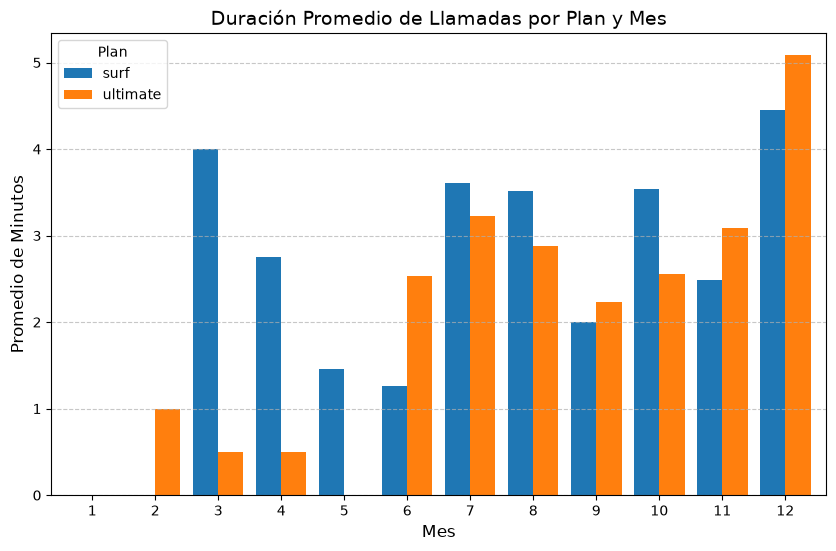

In [33]:
# Se comparo la duración promedio de llamadas por cada plan y por cada mes. Se trazo un gráfico de barras para visualizarla.
df_calls_avg = merged_data.groupby(['month', 'plan'])['cantidad_minutos'].mean().unstack()
ax = df_calls_avg.plot(kind='bar', figsize=(10, 6), width=0.8)
plt.title('Duración Promedio de Llamadas por Plan y Mes', fontsize=14)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Promedio de Minutos', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Plan')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

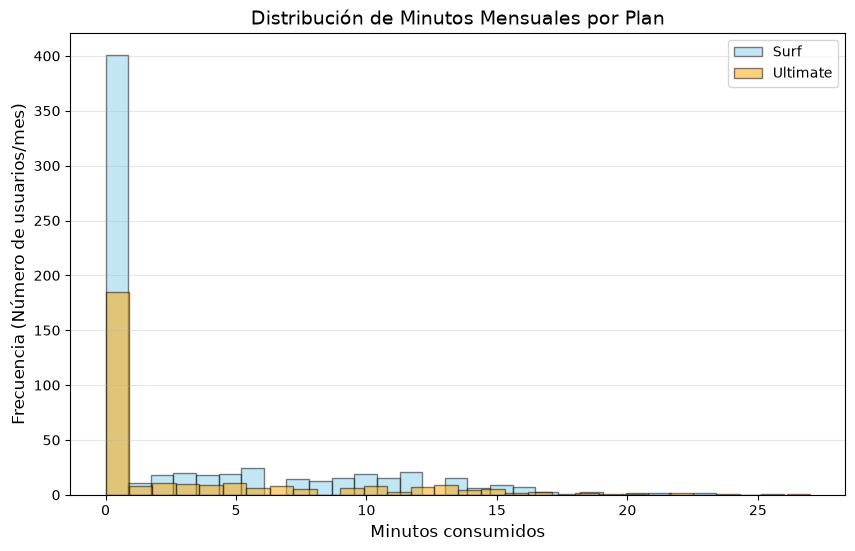

In [34]:
# Se realizo una comparación del número de minutos mensuales que necesitan los usuarios de cada plan. Se trazo un histograma.

surf_minutes = merged_data[merged_data['plan'] == 'surf']['cantidad_minutos']
ultimate_minutes = merged_data[merged_data['plan'] == 'ultimate']['cantidad_minutos']

plt.figure(figsize=(10, 6))
plt.hist(surf_minutes, bins=30, alpha=0.5, label='Surf', color='skyblue', edgecolor='black')
plt.hist(ultimate_minutes, bins=30, alpha=0.5, label='Ultimate', color='orange', edgecolor='black')

plt.title('Distribución de Minutos Mensuales por Plan', fontsize=14)
plt.xlabel('Minutos consumidos', fontsize=12)
plt.ylabel('Frecuencia (Número de usuarios/mes)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)

plt.show()

Nota. Otro de los requerimientos que nos dio la empresa Megaline fue el siguiente: Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.

In [35]:
# Se realizo el calculo de la media y la varianza de la duración mensual de llamadas.
stats_llamadas = merged_data.groupby('plan')['cantidad_minutos'].agg(['mean', 'var']).reset_index()
stats_llamadas.head()

,plan,mean,var
0,surf,3.289833,26.516173
1,ultimate,3.360390,29.833866


C:\Users\Abraham\AppData\Local\Temp\ipykernel_1892\1266612042.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='plan', y='cantidad_minutos', data=merged_data, palette='Set2')


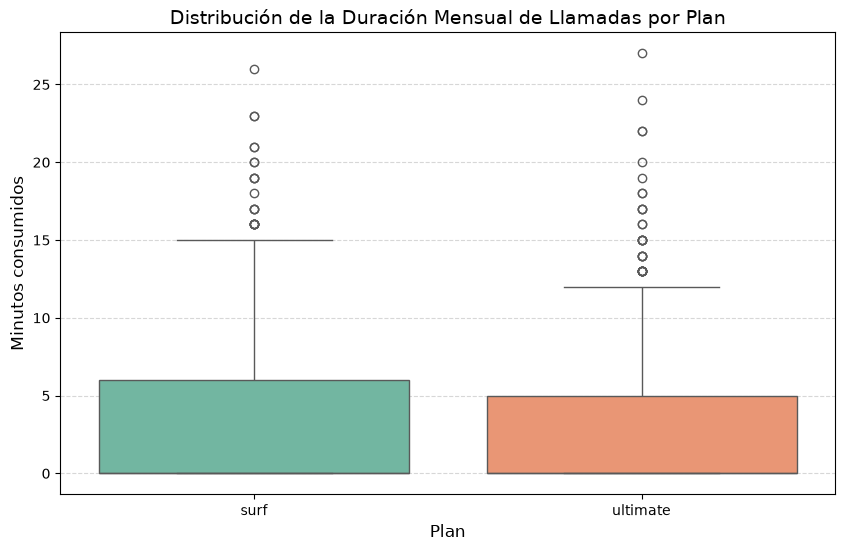

In [36]:
# Se marco la trazabilidad a través de un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
plt.figure(figsize=(10, 6))
sns.boxplot(x='plan', y='cantidad_minutos', data=merged_data, palette='Set2')

plt.title('Distribución de la Duración Mensual de Llamadas por Plan', fontsize=14)
plt.xlabel('Plan', fontsize=12)
plt.ylabel('Minutos consumidos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Significant Activity. Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a las llamadas. ¿Su comportamiento varía en función del plan?

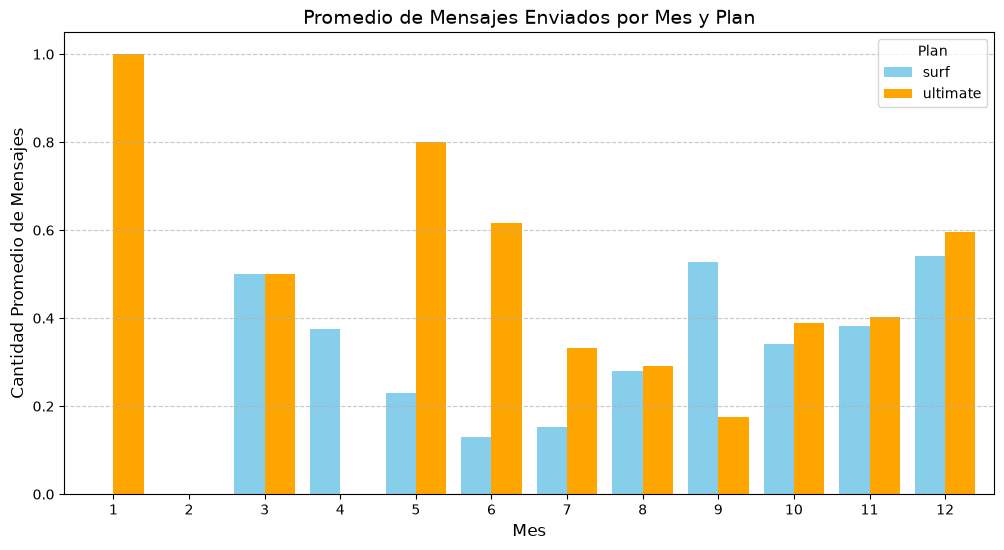

In [37]:
# Compara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
# Se realizo la comparativa de mensajes de cada mes por usuario en cada plan tarifario.
mensajes_promedio = merged_data.groupby(['month', 'plan'])['cantidad_mensajes'].mean().unstack()
mensajes_promedio.plot(kind='bar', figsize=(12, 6), width=0.8, color=['skyblue', 'orange'])

# Se traza una grafica de barras para representar el resultado obtenido en el paso anterior el cual ayudara al área comercial en toma de decisiones.
plt.title('Promedio de Mensajes Enviados por Mes y Plan', fontsize=14)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Cantidad Promedio de Mensajes', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Plan')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

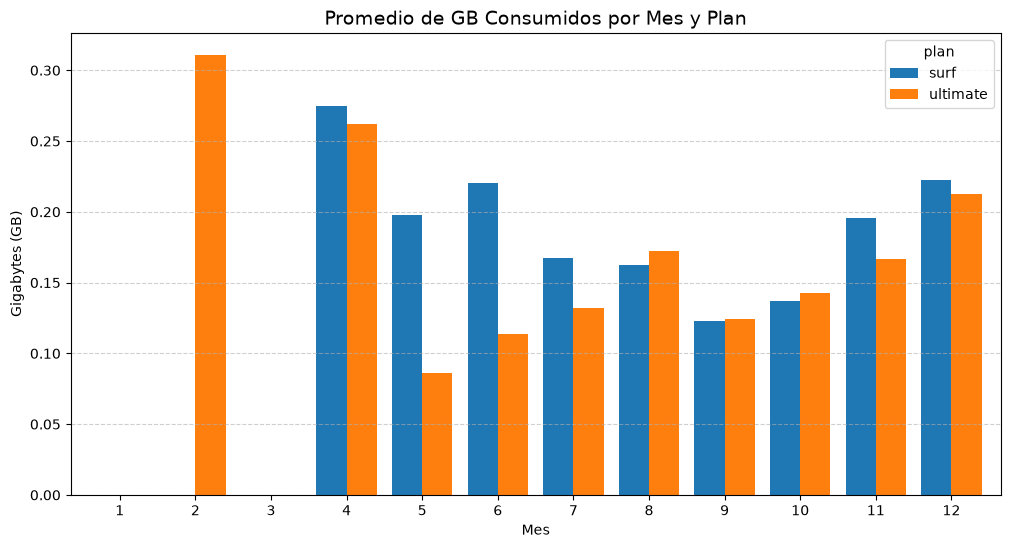

In [38]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan.
# Se hizo la comparativa de cantidad del trafico de internet consumido y al mismo tiempo se traza una grafica para respaldar los resultados
# ante el área comercial y mejorar la fase de análisis para ellos.

internet_mensual = merged_data.groupby(['month', 'plan'])['gb_used'].mean().unstack()
internet_mensual.plot(kind='bar', figsize=(12, 6), width=0.8)
plt.title('Promedio de GB Consumidos por Mes y Plan', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('Gigabytes (GB)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

Results.
Basado en todo el análisis de los datos y cada una de las visualizaciones que se realizaron se enlistan las conclusiones mas relevantes:

Relación con los limites de cada plan Surf Vs Iltimate:
En relación con los usuarios SURF: Se puede apreciar que hay una tendecnia clara y precisa al momento de consumir cerca o ligeramente por encima del limite de 15GB, esto basado en el diagrama de "caja" que se hizo donde se observa que la mediana está muy próxima a este umbral, mostrando que el excedente de datos es la causa raíz de los ingresos variables para el plan SURF.
En relación con los usuarios ULTIMATE: Existe una gran diferencia empezando con el limite que tiende a ser mayor (30GB), esto se debe a que la mayoría de los usuarios no consume el doble que los usuarios SURF. ¿A que se debé esto? Se debé a que su consumo es más relajado, en ocasiones logran alcanzar el limite, basado en esto se puede determinar que este plan ULTIMATE en su mayoria es contratado y pagado por lo usuarios por "tranquilidad" que por necesidad personal o necesidad técnica.
Temporalidad y Crecimiento:
En general y hablando de ambos planes (SURF y ULTIMATE), se muestra un crecimiento gradual mes a mes desde enero hasta diciembre.
Como bien se menciono todo esto es en ambos planes por razones y/o factores externos (Festividades durante todo el año, mayor uso de apps) estos factores sostienen la teoría de que la Te
mporalidad y Crecimiento es igual para ambos planes.
Mi conclusión general es:

Los usuarios de SURF tratan de optimizar y sacar el mayor rendimiento al plan claro sin excederse de su limite, mientras que los de ULTIMATE dejan ver una libertad de uso en su plan lo que resulta una mayor varianza pero enfocado en tener siempre una eficiencia de uso de paquete mucho mejor en todos los sentidos.

Significant Activity. Prueba las hipótesis estadísticas

In [45]:
# Prueba las hipótesis

ingresos_surf = merged_data[merged_data['plan'] == 'surf']['ingreso_mensual']
ingresos_ultimate = merged_data[merged_data['plan'] == 'ultimate']['ingreso_mensual']
alpha = 0.05

results = st.ttest_ind(ingresos_surf, ingresos_ultimate, equal_var=False)
print(f'Valor p: {results.pvalue}')
if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula: hay una diferencia significativa en los ingresos.")
else:
    print("No podemos rechazar la hipótesis nula: no hay evidencia de diferencia significativa.")

Valor p: 0.0
Rechazamos la hipótesis nula: hay una diferencia significativa en los ingresos.


C:\Users\Abraham\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [46]:
# Prueba las hipótesis
ny_nj_users = merged_data[merged_data['city'].str.contains('NY-NJ', na=False)]['ingreso_mensual']
other_users = merged_data[~merged_data['city'].str.contains('NY-NJ', na=False)]['ingreso_mensual']

alpha = 0.05
results = st.ttest_ind(ingresos_surf, ingresos_ultimate, equal_var=False)

print(f'Valor p: {results.pvalue}')

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula: hay una diferencia significativa en los ingresos.")
else:
    print("No podemos rechazar la hipótesis nula: no hay evidencia de diferencia significativa.")

Valor p: 0.0
Rechazamos la hipótesis nula: hay una diferencia significativa en los ingresos.


Conclusión General del Proyecto.

Partiendo del análisis integral del comportamiento de los usuarios y el rendimiento financiero de las suscripciones, se estructuran las siguientes conclusiones clave:
1. Comportamiento en el Consumo de Servicios
   * Tráfico de Datos (Internet): El consumo de datos móviles es el principal catalizador de uso en ambos segmentos. Los usuarios del plan Surf tienden a maximizar la cuota contratada, superando con frecuencia su límite de 15 GB. En contraste, los usuarios del plan Ultimate disfrutan de mayor holgura operativa, manteniendo un consumo promedio dentro del margen que ofrece su cuota de 30 GB.Llamadas y Mensajes (SMS): Ambos planes cubren holgadamente la demanda operativa de los usuarios. Se identificó una estacionalidad al cierre del año (cuarto trimestre), donde el volumen de llamadas y mensajes incrementa de manera uniforme en ambas suscripciones, sin reflejar diferencias estadísticamente significativas entre los grupos.
3. Análisis del Modelo de IngresosRentabilidad Variable (Plan Surf): Con una tarifa base accesible ($20 USD), este plan representa un motor de ingresos relevante gracias a la recurrencia de cargos por exceso de datos. La variabilidad en los patrones de consumo genera un margen significativo proveniente de las penalizaciones por excedentes.Rentabilidad Estable (Plan Ultimate): Presenta una dinámica opuesta: su tarifa base más elevada ($70 USD) asegura un flujo de ingresos predecible y constante para la empresa. Los usuarios rara vez superan los límites del plan, lo que minimiza el ingreso por excedentes.
4. Resultados de la Prueba de HipótesisDiferencia de Ingresos por Tipo de Plan: Se rechazó la hipótesis nula ($H_0$), confirmando con significancia estadística que los ingresos promedios de los planes Surf y Ultimate son notoriamente distintos. La elección del nivel de suscripción es el factor determinante en la facturación por usuario.Impacto Geográfico en el Consumo: No se encontró evidencia suficiente para rechazar la hipótesis nula ($H_0$). Los patrones de gasto de los usuarios de la zona metropolitana de NY-NJ no difieren del resto del país. Se concluye que el comportamiento de consumo está supeditado al tipo de contrato y no a la ubicación geográfica.